### Audio automatic labeling

To do the labeling the features to extract the information are:
- Short-time Energy
- Envelope Detection
- Spectral Flux

The audio folder will serve as an intput of informations, then applying this three methods of feature extraction, the information regarding the sudden change on the audio .wav will be recorded into a csv file with information of the time and respective feature.

In [3]:
!pip install pandas

In [4]:
import os
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import hilbert, find_peaks

In [5]:
def get_time_intervals(peaks, hop_length, sr, gap_threshold=0.1):
    """
    Convert frame indices (peaks) to time intervals.
    An interval is created when a gap larger than gap_threshold is encountered.
    """
    intervals = []
    start = None
    for t in peaks * hop_length / sr:
        if start is None:
            start = t
        elif t - start > gap_threshold:  # A gap larger than threshold indicates a separate event
            intervals.append((start, t))
            start = None
    if start is not None:
        intervals.append((start, start))
    return intervals

def merge_intervals(intervals, merge_threshold=0.1):
    """
    Merge overlapping or adjacent intervals.
    Two intervals are merged if the gap between them is less than or equal to merge_threshold.
    """
    if not intervals:
        return intervals

    # Sort intervals by their start time
    intervals = sorted(intervals, key=lambda x: x[0])
    merged = [intervals[0]]
    for current in intervals[1:]:
        last = merged[-1]
        # Check if current interval overlaps or is close enough to merge
        if current[0] - last[1] <= merge_threshold:
            # Merge: extend the last interval's end time if needed
            merged[-1] = (last[0], max(last[1], current[1]))
        else:
            merged.append(current)
    return merged

def compute_features(audio_path, sr=44100, frame_length=1024, hop_length=512):
    y, sr = librosa.load(audio_path, sr=sr)
    time = np.arange(len(y)) / sr
    
    # Short-Time Energy (STE)
    energy = np.array([
        np.sum(np.abs(y[i:i+frame_length])**2)
        for i in range(0, len(y)-frame_length, hop_length)
    ])
    
    # Envelope Detection
    analytic_signal = hilbert(y)
    envelope = np.abs(analytic_signal)
    envelope_smoothed = np.convolve(envelope, np.ones(1000)/1000, mode='same')
    
    # Spectral Flux
    spectrogram = np.abs(librosa.stft(y, n_fft=2048, hop_length=hop_length))
    spectral_flux = np.sqrt(np.sum(np.diff(spectrogram, axis=1)**2, axis=0))
    
    # Find Peaks (change points) for each feature
    energy_peaks, _ = find_peaks(energy, height=np.mean(energy) + 1.5 * np.std(energy))
    envelope_peaks, _ = find_peaks(envelope_smoothed, height=np.mean(envelope_smoothed) + 1.5 * np.std(envelope_smoothed))
    spectral_peaks, _ = find_peaks(spectral_flux, height=np.mean(spectral_flux) + 1.5 * np.std(spectral_flux))
    
    # Get raw intervals from peaks
    energy_intervals = get_time_intervals(energy_peaks, hop_length, sr, gap_threshold=0.1)
    envelope_intervals = get_time_intervals(envelope_peaks, hop_length, sr, gap_threshold=0.1)
    spectral_intervals = get_time_intervals(spectral_peaks, hop_length, sr, gap_threshold=0.1)
    
    # Merge overlapping or close intervals for each feature
    energy_intervals = merge_intervals(energy_intervals, merge_threshold=0.1)
    envelope_intervals = merge_intervals(envelope_intervals, merge_threshold=0.1)
    spectral_intervals = merge_intervals(spectral_intervals, merge_threshold=0.1)
    
    return energy_intervals, envelope_intervals, spectral_intervals

def process_audio_files(input_folder, output_csv):
    results = []
    for filename in os.listdir(input_folder):
        if filename.endswith(".wav"):
            file_path = os.path.join(input_folder, filename)
            energy_intervals, envelope_intervals, spectral_intervals = compute_features(file_path)
            
            for start, end in energy_intervals:
                results.append({"Filename": filename, "Start Time (s)": start, "End Time (s)": end, "Detected Feature": "Energy"})
            for start, end in envelope_intervals:
                results.append({"Filename": filename, "Start Time (s)": start, "End Time (s)": end, "Detected Feature": "Envelope"})
            for start, end in spectral_intervals:
                results.append({"Filename": filename, "Start Time (s)": start, "End Time (s)": end, "Detected Feature": "Spectral Flux"})
    
    df = pd.DataFrame(results)
    df.to_csv(output_csv, index=False)
    print(f"Results saved to {output_csv}")

input_folder = r"C:\Users\Teresa\Desktop\MBBAS (2ºano)\Tese\Audio_samples"  # Folder containing .wav files
output_csv = "tempos_deglutiçao.csv"
process_audio_files(input_folder, output_csv)

Results saved to tempos_deglutiçao.csv


##### The csv file contains the name of the wav file, start time, end time and detected feature

### Visualization of csv file

In [6]:
import pandas as pd

df = pd.read_csv('tempos_deglutiçao.csv')
df

,Filename,Start Time (s),End Time (s),Detected Feature
0,GC_F1-10ml.wav,2.821224,3.076644,Energy
1,GC_F1-10ml.wav,3.297234,3.297234,Energy
2,GC_F1-10ml.wav,1437.187483,1450.573787,Envelope
3,GC_F1-10ml.wav,1452.001814,1545.659501,Envelope
4,GC_F1-10ml.wav,1554.692063,1558.244717,Envelope
...,...,...,...,...
351,GE_M1_5ml.wav,4587.113651,4589.180227,Envelope
352,GE_M1_5ml.wav,4617.624671,4623.998549,Envelope
353,GE_M1_5ml.wav,5633.637007,5661.988571,Envelope
354,GE_M1_5ml.wav,5664.542766,5851.022222,Envelope


In [7]:
import numpy as np
import librosa
import librosa.display
import scipy.signal
import pandas as pd
import matplotlib.pyplot as plt

Deglutition event detected from 2.626s to 3.326s.


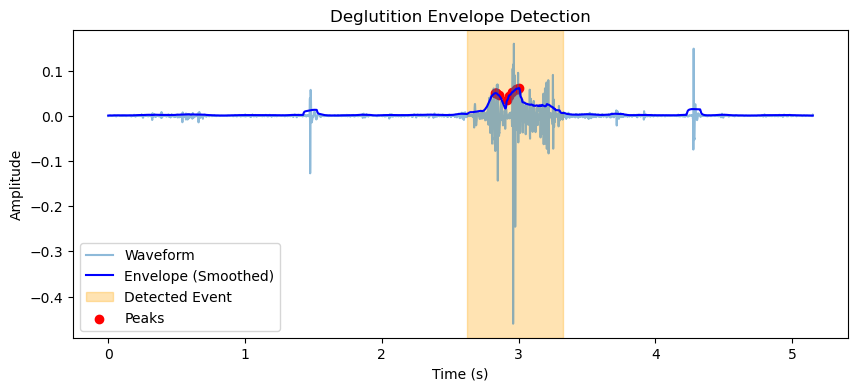

In [8]:
# Load the audio file
audio_path = r"C:\Users\Teresa\Desktop\MBBAS (2ºano)\Tese\Audio_samples\GC_F1-3ml.wav" 
y, sr = librosa.load(audio_path, sr=None)  # Load with original sampling rate

# Compute envelope using the Hilbert transform
analytic_signal = scipy.signal.hilbert(y)
amplitude_envelope = np.abs(analytic_signal)

# Smooth the envelope with a moving average filter
window_size = int(sr * 0.1)  # 100ms window
smoothed_envelope = np.convolve(amplitude_envelope, np.ones(window_size)/window_size, mode='same')

# Detect peaks in the envelope
peaks, _ = scipy.signal.find_peaks(smoothed_envelope, height=np.max(smoothed_envelope) * 0.5)

# Convert peak indices to time values
peak_times = peaks / sr

# Extract start and end time of the deglutition event (assuming one main peak)
if len(peak_times) > 0:
    event_start = max(0, peak_times[0] - 0.2)  # 200ms before the peak
    event_end = min(len(y) / sr, peak_times[0] + 0.5)  # 500ms after the peak

    # Save to CSV
    df = pd.DataFrame({"Start_Time": [event_start], "End_Time": [event_end]})
    df.to_csv("deglutition_event.csv", index=False)

    print(f"Deglutition event detected from {event_start:.3f}s to {event_end:.3f}s.")

    # Plot waveform and envelope with highlighted event
    plt.figure(figsize=(10, 4))
    time_axis = np.linspace(0, len(y) / sr, len(y))

    plt.plot(time_axis, y, alpha=0.5, label="Waveform")
    plt.plot(time_axis, smoothed_envelope, 'b', label="Envelope (Smoothed)")
    
    # Highlight deglutition event
    plt.axvspan(event_start, event_end, color='orange', alpha=0.3, label="Detected Event")
    
    # Mark peaks
    plt.scatter(peak_times, [smoothed_envelope[peaks[i]] for i in range(len(peaks))], color='red', label="Peaks")

    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.title("Deglutition Envelope Detection")
    plt.show()
else:
    print("No clear deglutition event detected.")

In [9]:
# Folder containing the WAV files
folder_path = r"C:\Users\Teresa\Desktop\MBBAS (2ºano)\Tese\Audio_samples" 
output_csv = "deglutition_events.csv"  # Output CSV file

# List to store results
results = []

# Process each WAV file in the folder
for file_name in os.listdir(folder_path):
    if file_name.endswith(".wav"):  # Only process WAV files
        audio_path = os.path.join(folder_path, file_name)
        print(f"Processing: {file_name}")

        # Load audio
        y, sr = librosa.load(audio_path, sr=None)

        # Compute envelope using Hilbert transform
        analytic_signal = scipy.signal.hilbert(y)
        amplitude_envelope = np.abs(analytic_signal)

        # Smooth the envelope
        window_size = int(sr * 0.1)  # 100ms window
        smoothed_envelope = np.convolve(amplitude_envelope, np.ones(window_size) / window_size, mode='same')

        # Detect peaks in the envelope
        peaks, _ = scipy.signal.find_peaks(smoothed_envelope, height=np.max(smoothed_envelope) * 0.5)
        peak_times = peaks / sr  # Convert to seconds

        # Extract time interval for deglutition event
        if len(peak_times) > 0:
            event_start = max(0, peak_times[0] - 0.2)  # 200ms before peak
            event_end = min(len(y) / sr, peak_times[0] + 0.5)  # 500ms after peak
            results.append([file_name, event_start, event_end])
            print(f"  Detected event: {event_start:.3f}s to {event_end:.3f}s")
        else:
            print(f"  No clear deglutition event detected.")

# Save results to CSV
df = pd.DataFrame(results, columns=["File_Name", "Start_Time", "End_Time"])
df.to_csv(output_csv, index=False)
print(f"\nAll results saved to {output_csv}")


Processing: GC_F1-10ml.wav
  Detected event: 3.095s to 3.795s
Processing: GC_F1-20ml.wav
  Detected event: 3.360s to 4.060s
Processing: GC_F1-3ml.wav
  Detected event: 2.626s to 3.326s
Processing: GC_F1-50ml.wav
  Detected event: 2.239s to 2.939s
Processing: GC_F1-5ml.wav
  Detected event: 1.154s to 1.854s
Processing: GC_F2_10ML.wav
  Detected event: 3.199s to 3.899s
Processing: GC_F2_20Ml.wav
  Detected event: 2.727s to 3.427s
Processing: GC_F2_3Ml.wav
  Detected event: 2.692s to 3.392s
Processing: GC_F2_50ML.wav
  Detected event: 2.497s to 3.197s
Processing: GC_F2_5ml.wav
  Detected event: 4.473s to 5.173s
Processing: GE-M1-3ml.wav
  Detected event: 8.710s to 9.410s
Processing: GE_F1-10ML.wav
  Detected event: 8.520s to 9.220s
Processing: GE_F1_3ML.wav
  Detected event: 7.120s to 7.820s
Processing: GE_F1_5ML.wav
  Detected event: 5.125s to 5.825s
Processing: GE_M1-20ml.wav
  Detected event: 10.508s to 11.207s
Processing: GE_M1_10ml.wav
  Detected event: 10.723s to 11.423s
Processing:

### Grupo controlo

##### Need to verify if the envelope detection can detect multiple swallow events

Deglutition event detected from 2.497s to 3.197s.


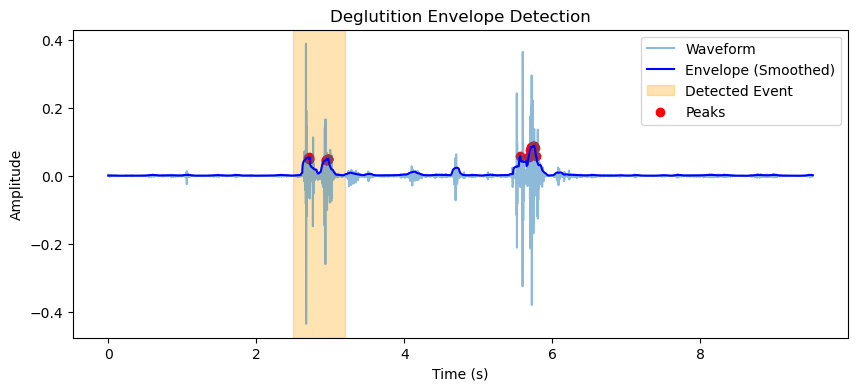

In [10]:
# Load the audio file
audio_path = r"C:\Users\Teresa\Desktop\MBBAS (2ºano)\Tese\Audio_samples\GC_F2_50ML.wav" 
y, sr = librosa.load(audio_path, sr=None)  # Load with original sampling rate

# Compute envelope using the Hilbert transform
analytic_signal = scipy.signal.hilbert(y)
amplitude_envelope = np.abs(analytic_signal)

# Smooth the envelope with a moving average filter
window_size = int(sr * 0.1)  # 100ms window
smoothed_envelope = np.convolve(amplitude_envelope, np.ones(window_size)/window_size, mode='same')

# Detect peaks in the envelope
peaks, _ = scipy.signal.find_peaks(smoothed_envelope, height=np.max(smoothed_envelope) * 0.5)

# Convert peak indices to time values
peak_times = peaks / sr

# Extract start and end time of the deglutition event (assuming one main peak)
if len(peak_times) > 0:
    event_start = max(0, peak_times[0] - 0.2)  # 200ms before the peak
    event_end = min(len(y) / sr, peak_times[0] + 0.5)  # 500ms after the peak

    # Save to CSV
    df = pd.DataFrame({"Start_Time": [event_start], "End_Time": [event_end]})
    df.to_csv("deglutition_event.csv", index=False)

    print(f"Deglutition event detected from {event_start:.3f}s to {event_end:.3f}s.")

    # Plot waveform and envelope with highlighted event
    plt.figure(figsize=(10, 4))
    time_axis = np.linspace(0, len(y) / sr, len(y))

    plt.plot(time_axis, y, alpha=0.5, label="Waveform")
    plt.plot(time_axis, smoothed_envelope, 'b', label="Envelope (Smoothed)")
    
    # Highlight deglutition event
    plt.axvspan(event_start, event_end, color='orange', alpha=0.3, label="Detected Event")
    
    # Mark peaks
    plt.scatter(peak_times, [smoothed_envelope[peaks[i]] for i in range(len(peaks))], color='red', label="Peaks")

    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.title("Deglutition Envelope Detection")
    plt.show()
else:
    print("No clear deglutition event detected.")

##### New updated code to detect multiple swallows

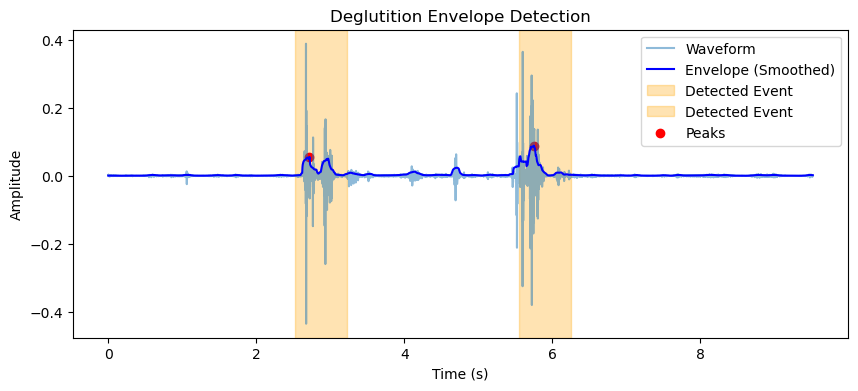

In [23]:
# Load the audio file
audio_path = r"C:\Users\Teresa\Desktop\MBBAS (2ºano)\Tese\Audio_samples\GC_F2_50ML.wav"
y, sr = librosa.load(audio_path, sr=None)

# Compute envelope using Hilbert transform
analytic_signal = scipy.signal.hilbert(y)
amplitude_envelope = np.abs(analytic_signal)

# Smooth the envelope with a moving average filter
window_size = int(sr * 0.1)  # 100ms window
smoothed_envelope = np.convolve(amplitude_envelope, np.ones(window_size)/window_size, mode='same')

# Detect peaks in the envelope
peaks, _ = scipy.signal.find_peaks(smoothed_envelope, height=np.max(smoothed_envelope) * 0.4, distance=sr*0.5)
peak_times = peaks / sr

# Extract start and end times for each detected event
events = [(max(0, t - 0.2), min(len(y) / sr, t + 0.5)) for t in peak_times]

# ---- PLOT WAVEFORM ----
plt.figure(figsize=(10, 4))
time_axis = np.linspace(0, len(y) / sr, len(y))

plt.plot(time_axis, y, alpha=0.5, label="Waveform")
plt.plot(time_axis, smoothed_envelope, 'b', label="Envelope (Smoothed)")

# Highlight detected events
for start, end in events:
    plt.axvspan(start, end, color='orange', alpha=0.3, label="Detected Event")

# Mark detected peaks
plt.scatter(peak_times, smoothed_envelope[peaks], color='red', label="Peaks")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.title("Deglutition Envelope Detection")
plt.show()


100ms window  --> se ajustar para um valor superior a janela adapta-se do segundo gole e 'apanha' o inicio

#### Grupo experimental

Deglutition event detected from 7.120s to 7.820s.


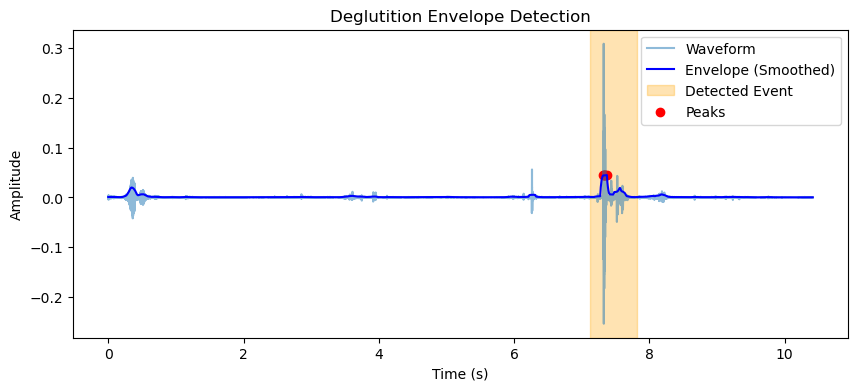

In [22]:
# Load the audio file
audio_path = r"C:\Users\Teresa\Desktop\MBBAS (2ºano)\Tese\Audio_samples\GE_F1_3ML.wav"
y, sr = librosa.load(audio_path, sr=None)  # Load with original sampling rate

# Compute envelope using the Hilbert transform
analytic_signal = scipy.signal.hilbert(y)
amplitude_envelope = np.abs(analytic_signal)

# Smooth the envelope with a moving average filter
window_size = int(sr * 0.1)  # 100ms window
smoothed_envelope = np.convolve(amplitude_envelope, np.ones(window_size)/window_size, mode='same')

# Detect peaks in the envelope
peaks, _ = scipy.signal.find_peaks(smoothed_envelope, height=np.max(smoothed_envelope) * 0.5)

# Convert peak indices to time values
peak_times = peaks / sr

# Extract start and end time of the deglutition event (assuming one main peak)
if len(peak_times) > 0:
    event_start = max(0, peak_times[0] - 0.2)  # 200ms before the peak
    event_end = min(len(y) / sr, peak_times[0] + 0.5)  # 500ms after the peak

    # Save to CSV
    df = pd.DataFrame({"Start_Time": [event_start], "End_Time": [event_end]})
    df.to_csv("deglutition_event.csv", index=False)

    print(f"Deglutition event detected from {event_start:.3f}s to {event_end:.3f}s.")

    # Plot waveform and envelope with highlighted event
    plt.figure(figsize=(10, 4))
    time_axis = np.linspace(0, len(y) / sr, len(y))

    plt.plot(time_axis, y, alpha=0.5, label="Waveform")
    plt.plot(time_axis, smoothed_envelope, 'b', label="Envelope (Smoothed)")
    
    # Highlight deglutition event
    plt.axvspan(event_start, event_end, color='orange', alpha=0.3, label="Detected Event")
    
    # Mark peaks
    plt.scatter(peak_times, [smoothed_envelope[peaks[i]] for i in range(len(peaks))], color='red', label="Peaks")

    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.title("Deglutition Envelope Detection")
    plt.show()
else:
    print("No clear deglutition event detected.")

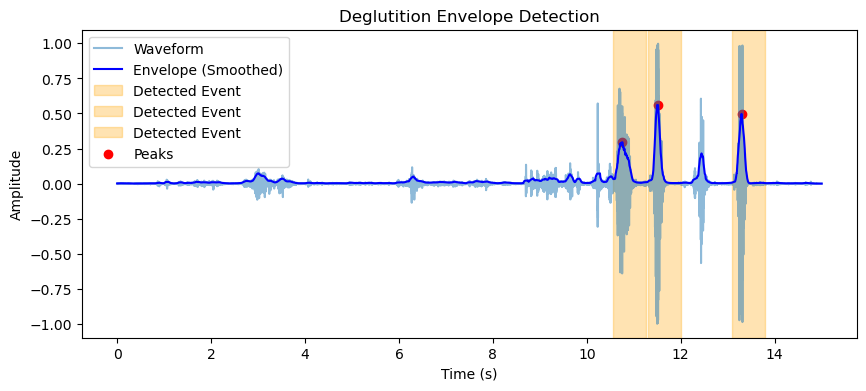

In [25]:
# Load the audio file
audio_path = r"C:\Users\Teresa\Desktop\MBBAS (2ºano)\Tese\Audio_samples\GE_M1-20ml.wav"
y, sr = librosa.load(audio_path, sr=None)

# Compute envelope using Hilbert transform
analytic_signal = scipy.signal.hilbert(y)
amplitude_envelope = np.abs(analytic_signal)

# Smooth the envelope with a moving average filter
window_size = int(sr * 0.1)  # 100ms window
smoothed_envelope = np.convolve(amplitude_envelope, np.ones(window_size)/window_size, mode='same')

# Detect peaks in the envelope
peaks, _ = scipy.signal.find_peaks(smoothed_envelope, height=np.max(smoothed_envelope) * 0.4, distance=sr*0.5)
peak_times = peaks / sr

# Extract start and end times for each detected event
events = [(max(0, t - 0.2), min(len(y) / sr, t + 0.5)) for t in peak_times]

# ---- PLOT WAVEFORM ----
plt.figure(figsize=(10, 4))
time_axis = np.linspace(0, len(y) / sr, len(y))

plt.plot(time_axis, y, alpha=0.5, label="Waveform")
plt.plot(time_axis, smoothed_envelope, 'b', label="Envelope (Smoothed)")

# Highlight detected events
for start, end in events:
    plt.axvspan(start, end, color='orange', alpha=0.3, label="Detected Event")

# Mark detected peaks
plt.scatter(peak_times, smoothed_envelope[peaks], color='red', label="Peaks")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.title("Deglutition Envelope Detection")
plt.show()
